In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_excel("Professional_Sales_vs_Demand_Dataset.xlsx")

print("="*50)
print("FIRST 5 ROWS")
print(df.head())

print("="*50)
print("LAST 5 ROWS")
print(df.tail())

FIRST 5 ROWS
  Month  Sales  Demand  Price  Discount(%)  MarketingSpend  Inventory   Profit
0   Jan    791    1587  21.14           15           36625        763 -1513.98
1   Feb    869    1517  19.40           15           23187        797   534.30
2   Mar    455     770  20.33           10            9986        386   833.14
3   Apr    563    1472  18.73            5           44530        590 -3874.53
4   May    667    1162  16.54           25           22191        762 -1011.89
LAST 5 ROWS
    Month  Sales  Demand  Price  Discount(%)  MarketingSpend  Inventory  \
295   Aug    374    1147  21.19            0           40013        417   
296   Sep    635    1378  27.87           15           34615        712   
297   Oct    485    1428  19.08           15           49679        444   
298   Nov    449    1063  14.25            0           28136        372   
299   Dec   1182    1814  27.63           20           10945       1129   

      Profit  
295 -3782.93  
296  -980.26  
297 -

In [3]:
print("="*50)
print("DATASET INFORMATION")
print(df.info())

print("="*50)
print("SHAPE")
print(df.shape)

print("="*50)
print("STATISTICAL SUMMARY")
print(df.describe())

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Month           300 non-null    str    
 1   Sales           300 non-null    int64  
 2   Demand          300 non-null    int64  
 3   Price           300 non-null    float64
 4   Discount(%)     300 non-null    int64  
 5   MarketingSpend  300 non-null    int64  
 6   Inventory       300 non-null    int64  
 7   Profit          300 non-null    float64
dtypes: float64(2), int64(5), str(1)
memory usage: 18.9 KB
None
SHAPE
(300, 8)
STATISTICAL SUMMARY
             Sales       Demand       Price  Discount(%)  MarketingSpend  \
count   300.000000   300.000000  300.000000   300.000000      300.000000   
mean    683.363333  1341.046667   19.697400    12.750000    27566.423333   
std     287.623264   477.537991    4.508503     8.321759    13444.091851   
min     203.000000   286.000000   

In [4]:
print("MISSING VALUES")
print(df.isnull().sum())

print()

print("Duplicate Rows")
print(df.duplicated().sum())


MISSING VALUES
Month             0
Sales             0
Demand            0
Price             0
Discount(%)       0
MarketingSpend    0
Inventory         0
Profit            0
dtype: int64

Duplicate Rows
0


In [5]:
print(df.corr(numeric_only=True))

                   Sales    Demand     Price  Discount(%)  MarketingSpend  \
Sales           1.000000  0.900441 -0.079436     0.102925        0.083126   
Demand          0.900441  1.000000 -0.041774    -0.019267        0.497176   
Price          -0.079436 -0.041774  1.000000    -0.008843        0.050934   
Discount(%)     0.102925 -0.019267 -0.008843     1.000000       -0.059419   
MarketingSpend  0.083126  0.497176  0.050934    -0.059419        1.000000   
Inventory       0.976294  0.877880 -0.069870     0.101018        0.078402   
Profit          0.460415  0.085680  0.238042    -0.022929       -0.763427   

                Inventory    Profit  
Sales            0.976294  0.460415  
Demand           0.877880  0.085680  
Price           -0.069870  0.238042  
Discount(%)      0.101018 -0.022929  
MarketingSpend   0.078402 -0.763427  
Inventory        1.000000  0.455544  
Profit           0.455544  1.000000  


In [6]:
print("Average sales :", df["Sales"].mean())
print("Average Demand :",df["Demand"].mean())
print("Average Profit :",df["Profit"].mean())
print("Highest Sales :",df["Sales"].max())
print("Lowest Sales :",df["Sales"].min())



Average sales : 683.3633333333333
Average Demand : 1341.0466666666666
Average Profit : -884.7042333333334
Highest Sales : 1200
Lowest Sales : 203


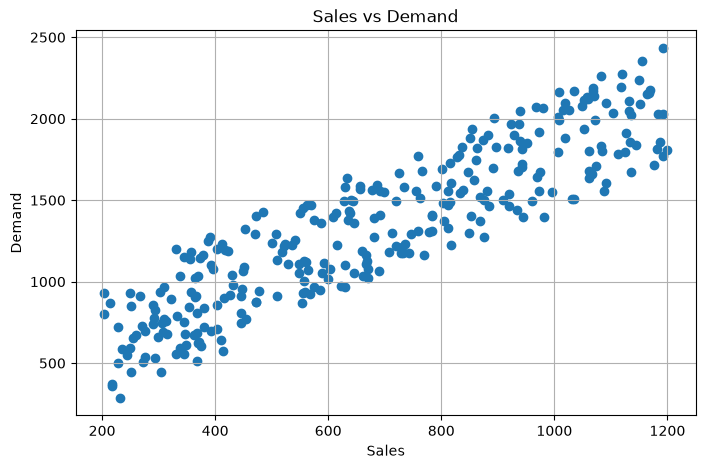

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(df["Sales"],df["Demand"])
plt.xlabel("Sales")
plt.ylabel("Demand")
plt.title("Sales vs Demand")
plt.grid()
plt.show()

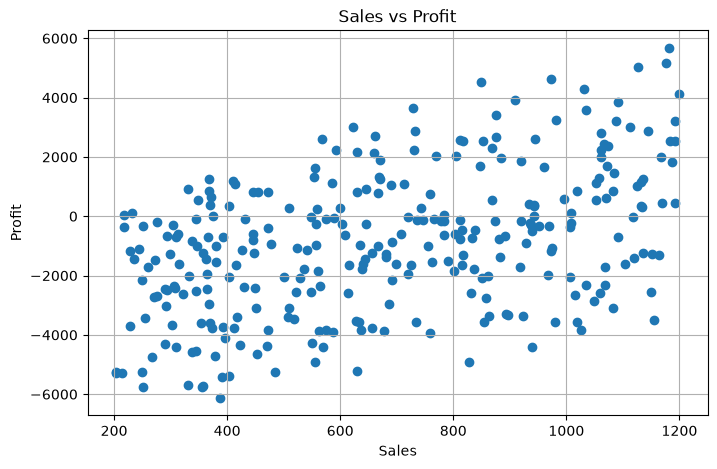

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(df["Sales"],df["Profit"])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")
plt.grid()
plt.show()


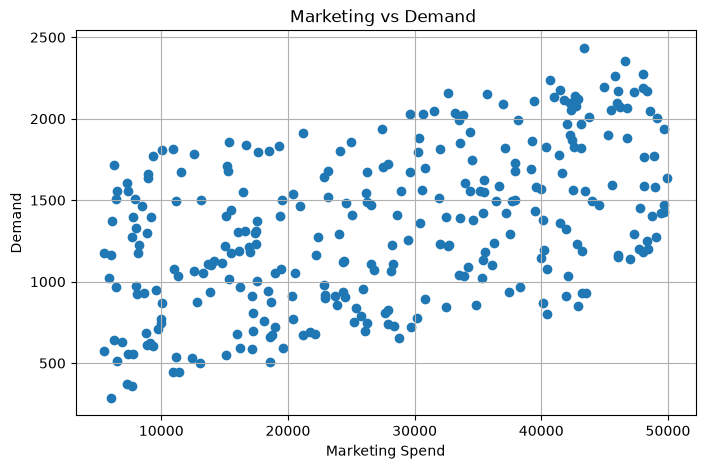

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(df["MarketingSpend"],df["Demand"])
plt.xlabel("Marketing Spend")
plt.ylabel("Demand")
plt.title("Marketing vs Demand ")
plt.grid()
plt.show()

In [10]:
x=df[["Sales"]]
y=df["Demand"]

In [11]:
x_train,X_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

In [14]:
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.51]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Sales']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,311.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [15]:
print("Intercept :",model.intercept_)
print("Slope :",model.coef_[0])
print()
print(f"Demand = {model.intercept_:.2f} + ({model.coef_[0]:.2f} × Sales)")


Intercept : 311.9117572211526
Slope : 1.5072544226283668

Demand = 311.91 + (1.51 × Sales)


In [16]:
y_pred=model.predict(X_test)

In [17]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
mape=np.mean(np.abs((y_test-y_pred)/y_test))*100
r2=r2_score(y_test,y_pred)
print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)
print("MAPE :",mape)
print("R2 Score :",r2)


MAE : 173.7881645506642
MSE : 39864.80526928992
RMSE : 199.66172710184074
MAPE : 16.314686463793652
R2 Score : 0.804843010153185


In [18]:
elasticity=model.coef_[0]*(df["Sales"].mean()/df["Demand"].mean())
print("Elasticity :",elasticity)

Elasticity : 0.7680585859021035


In [19]:
result=pd.DataFrame({
    "Actual Demand":y_test.values,
    "Predicted Demand":y_pred
})
print(result.head(20))


    Actual Demand  Predicted Demand
0            1185       1092.669548
1            1228       1543.338621
2             511        865.074130
3            1681       1912.615954
4             506        721.884960
5            1419       1235.858718
6            2179       2075.399432
7             965       1178.583050
8            1107       1317.250457
9            1310       1454.410610
10           1695       1654.875448
11           1668       1404.671214
12            679        785.189646
13            915        714.348688
14            678        833.421787
15            913        984.147230
16           1694       1520.729804
17           2169       1870.412830
18            672        703.797907
19           1122       1157.481488


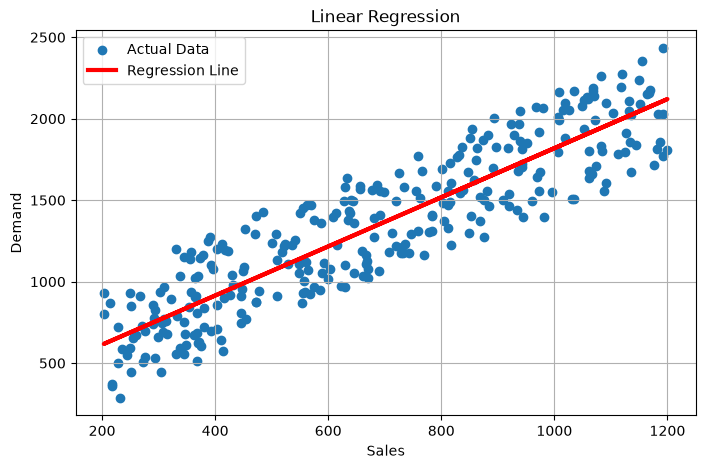

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(df["Sales"],df["Demand"],label="Actual Data")

plt.plot(df["Sales"],
model.predict(df[["Sales"]]),
color="red",
linewidth=3,
label="Regression Line"
)
plt.xlabel("Sales")
plt.ylabel("Demand")
plt.title("Linear Regression")
plt.legend()
plt.grid()
plt.show()

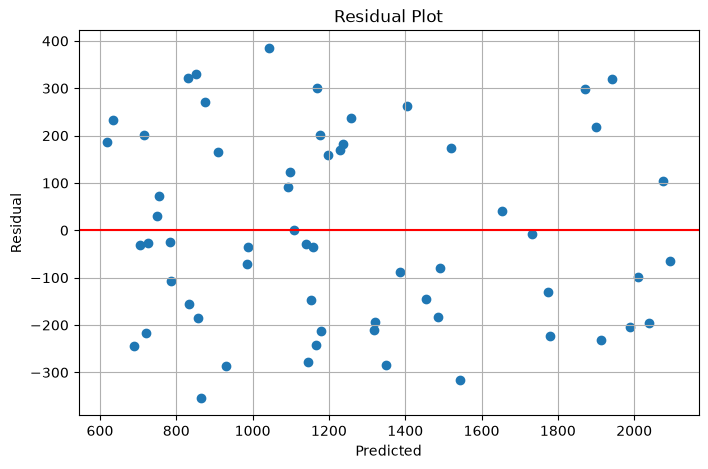

In [21]:
residual=y_test-y_pred
plt.figure(figsize=(8,5))
plt.scatter(y_pred,residual)
plt.axhline(y=0,color = "red")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.grid()
plt.show()

In [22]:
future_sales=1000
prediction=model.predict([[future_sales]])
print("Future sales :", future_sales)
print("Predicted Demand :",prediction[0])

Future sales : 1000
Predicted Demand : 1819.1661798495195


c:\Users\Hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
